In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
import seaborn as sns

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [7]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [8]:
df.shape    

(7043, 21)

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
# Count the number of customers in each class
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
# Count and percentage of each class
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [12]:
# churn column from categorical to numerical
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [13]:
df[["Churn"]].head()  

,Churn
0,0
1,0
2,1
3,0
4,1


In [14]:
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})

In [15]:
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})

In [16]:
df["DeviceProtection"] = df["DeviceProtection"].map({"Yes": 1, "No": 0})

In [17]:
df["TechSupport"] = df["TechSupport"].map({"Yes": 1, "No": 0})
df["StreamingTV"] = df["StreamingTV"].map({"Yes": 1, "No": 0})
df["StreamingMovies"] = df["StreamingMovies"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})


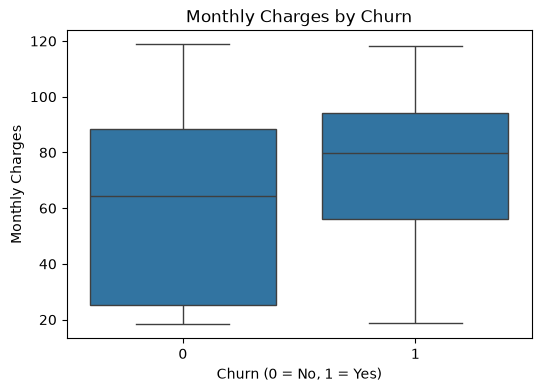

In [18]:
# Monthly Charges vs Churn
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()

churn for bigger monthly costs

In [19]:
print(df["TotalCharges"].dtype)

str


In [20]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

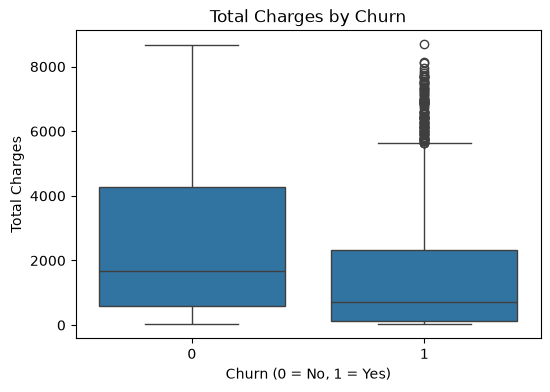

In [21]:
# Total Charges vs Churn
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Total Charges")
plt.show()

churn for newer customers (probably, there is no date for subscription start)

In [22]:
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

In [23]:
print(df["gender"].value_counts())

gender
1    3555
0    3488
Name: count, dtype: int64


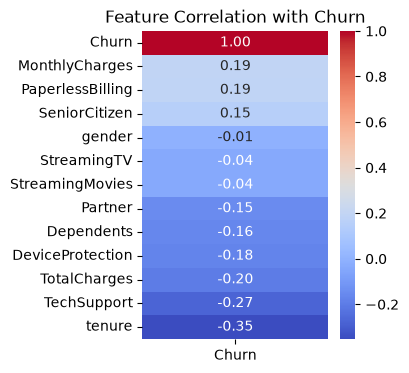

In [39]:
# Correlation of all numeric features with Churn
corr_with_churn = df.corr(numeric_only=True)[["Churn"]].sort_values(by="Churn", ascending=False)

plt.figure(figsize=(3, 4))
sns.heatmap(corr_with_churn,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlation with Churn")
plt.show()

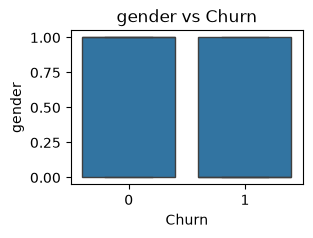

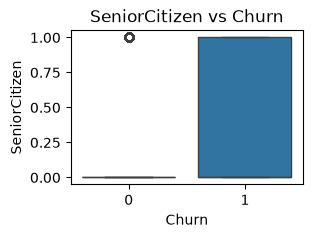

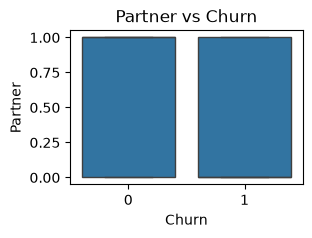

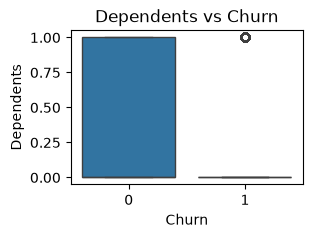

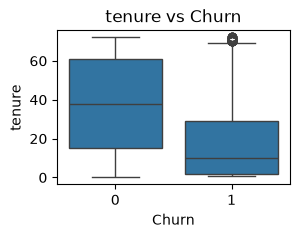

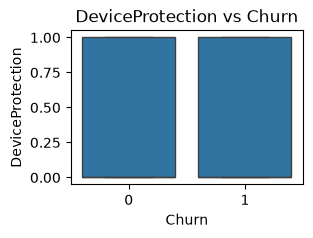

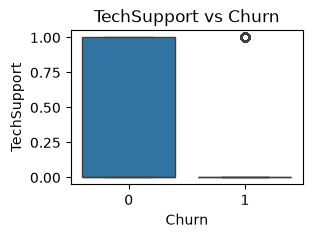

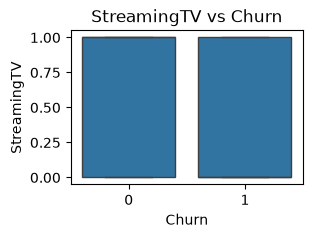

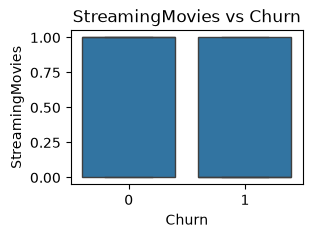

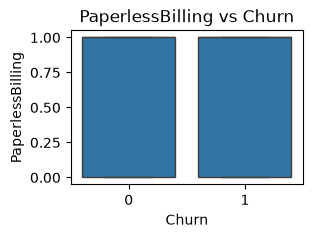

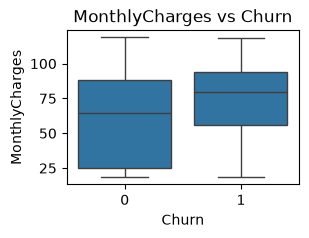

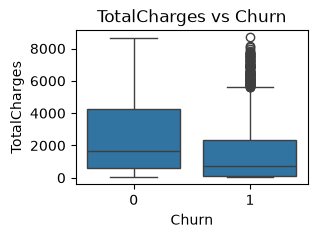

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select all numeric columns except the target
numeric_cols = df.select_dtypes(include=["number"]).columns.drop("Churn")

for col in numeric_cols:
    plt.figure(figsize=(3, 2))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

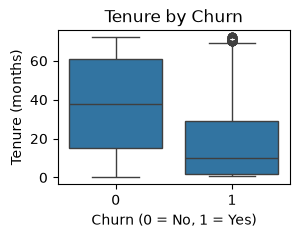

In [26]:
plt.figure(figsize=(3, 2))
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (months)")

plt.show()

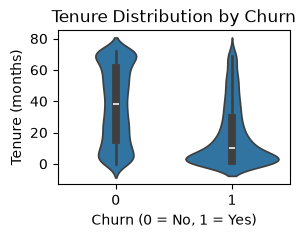

In [27]:
plt.figure(figsize=(3, 2))
sns.violinplot(x="Churn", y="tenure", data=df)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (months)")

plt.show()

In [28]:
print(df["InternetService"].unique())

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


In [29]:
print(df["InternetService"].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


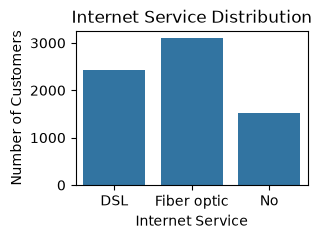

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 2))
sns.countplot(x="InternetService", data=df)

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

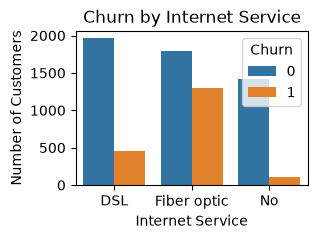

In [31]:
plt.figure(figsize=(3, 2))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

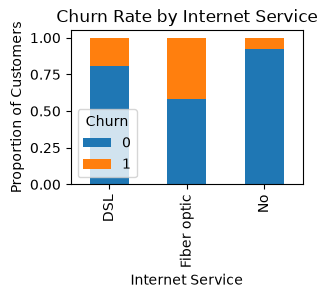

In [32]:
churn_rate = (
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index")
)

churn_rate.plot(kind="bar", stacked=True, figsize=(3, 2))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Proportion of Customers")
plt.legend(title="Churn")

plt.show()

In [33]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,No,No phone service,DSL,No,...,0.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,Yes,No,DSL,Yes,...,1.0,0.0,0.0,0.0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,Yes,No,DSL,Yes,...,0.0,0.0,0.0,0.0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,No,No phone service,DSL,Yes,...,1.0,1.0,0.0,0.0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,Yes,No,Fiber optic,No,...,0.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,70.70,151.65,1


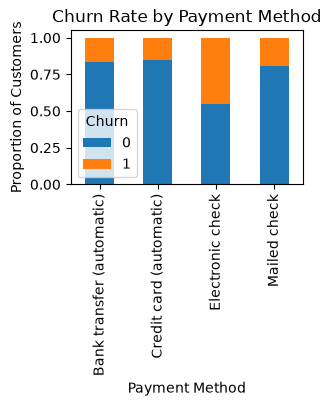

In [34]:
churn_rate = (
    pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")
)

churn_rate.plot(kind="bar", stacked=True, figsize=(3, 2))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Proportion of Customers")
plt.legend(title="Churn")

plt.show()

In [35]:
# one hot encoding for categorical variables

In [36]:
features = [
    "SeniorCitizen",
    "Dependents",
    "tenure",
    "TechSupport",
    "MonthlyCharges",
    "TotalCharges",
    "InternetService",
    "PaymentMethod"
]

df_model = df[features + ["Churn"]]

In [37]:
# One-hot encoding
df_model = pd.get_dummies(
    df_model,
    columns=["InternetService", "PaymentMethod"],
    drop_first=True
)

In [38]:
df_model.head()

,SeniorCitizen,Dependents,tenure,TechSupport,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0.0,29.85,29.85,0,False,False,False,True,False
1,0,0,34,0.0,56.95,1889.50,0,False,False,False,False,True
2,0,0,2,0.0,53.85,108.15,1,False,False,False,False,True
3,0,0,45,1.0,42.30,1840.75,0,False,False,False,False,False
4,0,0,2,0.0,70.70,151.65,1,True,False,False,True,False


Models that usually need scaling
    normalize/standardize:

✅ KNN
✅ Logistic Regression
✅ Support Vector Machines (SVM)
✅ Neural Networks
✅ K-means clustering
✅ PCA

For these models, scaling is important.

Models that usually do NOT need scaling



✅ Decision Trees
✅ Random Forest
✅ Gradient Boosting (XGBoost, LightGBM, CatBoost)

Important: avoid data leakage

Do not scale before splitting.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
scaler.fit(X_train)

# Transform both training and test data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)